Successfully located data file: ./Metro_Interstate_Traffic_Volume.csv
Dataset Shape: (48204, 9)

--- Training Models ---
Training Random Forest...
Training AdaBoost...
Training XGBoost...

--- Model Performance Comparison ---
                   RMSE      R2
Random Forest  441.2887  0.9507
AdaBoost       837.4095  0.8226
XGBoost        410.0885  0.9575


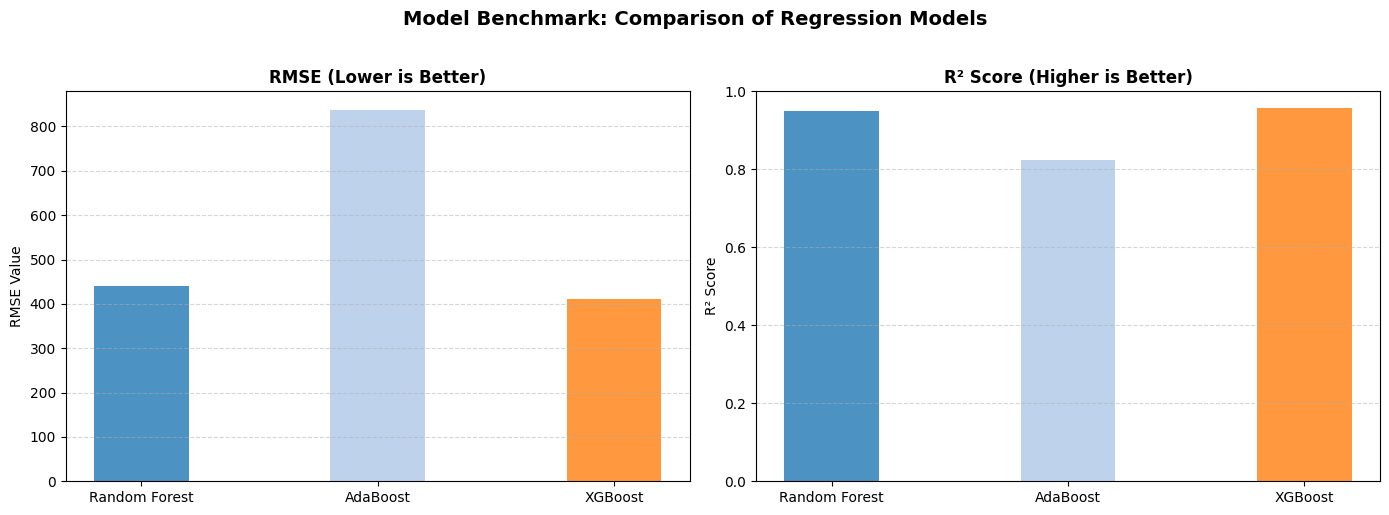

In [6]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# 1. Automatically Find and Extract Data
file_path = 'Metro_Interstate_Traffic_Volume.csv'

# If the CSV isn't found, check if a ZIP file was uploaded and extract it
if not os.path.exists(file_path):
    zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]
    if zip_files:
        print(f"Found compressed file {zip_files[0]}. Extracting...")
        with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
            zip_ref.extractall('.')

# Search for any CSV file in the workspace
csv_files = []
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv') and not file.startswith('._'):
            csv_files.append(os.path.join(root, file))

if csv_files:
    file_path = csv_files[0]
    print(f"Successfully located data file: {file_path}")
else:
    raise FileNotFoundError("Could not find the CSV file. Please upload 'Metro_Interstate_Traffic_Volume.csv' or the zip file to Colab.")

# Load dataset
df = pd.read_csv(file_path)
print("Dataset Shape:", df.shape)

# 2. Feature Engineering (Parsing Temporal Patterns)
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year

# Drop the raw timestamp column
df = df.drop(columns=['date_time'])

# Define Features and Target
X = df.drop(columns=['traffic_volume'])
y = df['traffic_volume']

# 3. Preprocessing Pipeline
numeric_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'year']
categorical_features = ['holiday', 'weather_main', 'weather_description']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# 5. Initialize Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=7, random_state=42, n_jobs=-1)
}

# 6. Train and Evaluate
results = {}

print("\n--- Training Models ---")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_preprocessed, y_train)

    # Predict
    preds = model.predict(X_test_preprocessed)

    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "R2": r2}

# 7. Print and Visualize Results
results_df = pd.DataFrame(results).T
print("\n--- Model Performance Comparison ---")
print(results_df.round(4))

# Fixed Plotting Section (Using clean side-by-side subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE
ax1.bar(results_df.index, results_df['RMSE'], color=['#1f77b4', '#aec7e8', '#ff7f0e'], alpha=0.8, width=0.4)
ax1.set_title('RMSE (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSE Value')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Plot R2 Score
ax2.bar(results_df.index, results_df['R2'], color=['#1f77b4', '#aec7e8', '#ff7f0e'], alpha=0.8, width=0.4)
ax2.set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
ax2.set_ylabel('R² Score')
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Model Benchmark: Comparison of Regression Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()